# Crop Fields (với Rectification + Enhancement)

Crop từng field sau khi warp thẻ về 856×540 và enhance ảnh.

**Pipeline mỗi ảnh:**
1. Lấy card bbox từ annotation → Rectify (warp 856×540)
2. Enhance (CLAHE + denoise)
3. Transform tọa độ field bbox sang ảnh đã warp
4. Crop field từ ảnh đã warp + enhance

**Đầu vào:**
- `data/processed/splits/train.json` + `val.json` (COCO JSON)
- Ảnh gốc từ `data/cccd.v1i.coco/`

**Đầu ra:**
- `data/interim/cropped_fields/{class}/{image_stem}_{ann_id}.jpg`
- `data/interim/cropped_fields/manifest.jsonl`

## 1. Setup

In [1]:
!pip install opencv-python matplotlib tqdm -q


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import json
import os
import sys
from collections import defaultdict
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

PROJECT_DIR = Path("d:/TaiLieuHocTap/Extraction ID Card")
os.chdir(PROJECT_DIR)
sys.path.insert(0, str(PROJECT_DIR))

from src.preprocessing.rectify import rectify, CARD_W, CARD_H
from src.preprocessing.enhance import enhance

RAW_DIR       = PROJECT_DIR / "data/cccd.v1i.coco"
SPLITS_DIR    = PROJECT_DIR / "data/processed/splits"
OUT_DIR       = PROJECT_DIR / "data/interim/cropped_fields"

FIELD_CLASSES = ["id", "name", "birth", "origin", "address", "title"]
PADDING       = 4
MIN_SIZE      = 10

for cls in FIELD_CLASSES:
    (OUT_DIR / cls).mkdir(parents=True, exist_ok=True)

fname_to_path = {}
for split in ["train", "valid", "test"]:
    for p in (RAW_DIR / split).glob("*.jpg"):
        fname_to_path[p.name] = p

print(f"{len(fname_to_path)} ảnh gốc")

4399 ảnh gốc


## 2. Crop fields

In [3]:
DST_CORNERS = np.array([
    [0,          0         ],
    [CARD_W - 1, 0         ],
    [CARD_W - 1, CARD_H - 1],
    [0,          CARD_H - 1],
], dtype=np.float32)


def transform_bbox(bbox_orig, M):
    """Biến đổi bbox [x,y,w,h] COCO sang tọa độ ảnh đã warp."""
    x, y, bw, bh = bbox_orig
    corners = np.array([
        [x,      y     ],
        [x + bw, y     ],
        [x + bw, y + bh],
        [x,      y + bh],
    ], dtype=np.float32).reshape(-1, 1, 2)
    warped_pts = cv2.perspectiveTransform(corners, M).reshape(-1, 2)
    x1 = max(0, int(warped_pts[:, 0].min()) - PADDING)
    y1 = max(0, int(warped_pts[:, 1].min()) - PADDING)
    x2 = min(CARD_W, int(warped_pts[:, 0].max()) + PADDING)
    y2 = min(CARD_H, int(warped_pts[:, 1].max()) + PADDING)
    return x1, y1, x2, y2


def crop_split(json_path: Path, split_name: str) -> list:
    with open(json_path, encoding="utf-8") as f:
        coco = json.load(f)

    cat_id_to_name = {c["id"]: c["name"] for c in coco["categories"]}
    img_id_to_info = {img["id"]: img for img in coco["images"]}

    # Nhóm annotation theo image_id
    card_by_img  = {}   # image_id → card bbox
    fields_by_img = defaultdict(list)  # image_id → list field ann

    for ann in coco["annotations"]:
        cls = cat_id_to_name.get(ann["category_id"])
        if cls == "card":
            card_by_img[ann["image_id"]] = ann["bbox"]
        elif cls in FIELD_CLASSES:
            fields_by_img[ann["image_id"]].append(ann)

    records = []
    skipped = 0

    for img_id, img_info in tqdm(img_id_to_info.items(), desc=f"  {split_name}", leave=False):
        src = fname_to_path.get(img_info["file_name"])
        if src is None:
            skipped += 1
            continue

        image = cv2.imread(str(src))
        if image is None:
            skipped += 1
            continue

        field_anns = fields_by_img.get(img_id, [])
        if not field_anns:
            continue

        # Rectify nếu có card bbox, fallback bbox toàn ảnh
        card_bbox = card_by_img.get(img_id)
        if card_bbox:
            x, y, bw, bh = card_bbox
            bbox_tuple = (x, y, x + bw, y + bh)
        else:
            h, w = image.shape[:2]
            bbox_tuple = (0, 0, w, h)

        rect = rectify(image, bbox_tuple)
        M    = cv2.getPerspectiveTransform(rect.corners, DST_CORNERS)

        # Enhance ảnh đã warp
        enh    = enhance(rect.image)
        warped = enh.image

        # Crop từng field
        stem = Path(img_info["file_name"]).stem
        for ann in field_anns:
            cls = cat_id_to_name[ann["category_id"]]
            x1, y1, x2, y2 = transform_bbox(ann["bbox"], M)

            if (x2 - x1) < MIN_SIZE or (y2 - y1) < MIN_SIZE:
                skipped += 1
                continue

            crop     = warped[y1:y2, x1:x2]
            out_name = f"{stem}_{ann['id']}.jpg"
            out_path = OUT_DIR / cls / out_name
            cv2.imwrite(str(out_path), crop)

            records.append({
                "path":         str(out_path.relative_to(PROJECT_DIR)),
                "class":        cls,
                "split":        split_name,
                "source_image": img_info["file_name"],
                "ann_id":       ann["id"],
                "bbox":         [x1, y1, x2, y2],
                "width":        x2 - x1,
                "height":       y2 - y1,
                "rectified":    not rect.failed,
            })

    print(f"  {split_name}: {len(records)} crops, bỏ qua {skipped}")
    return records


all_records = []
for split_name, fname in [("train", "train.json"), ("val", "val.json")]:
    all_records.extend(crop_split(SPLITS_DIR / fname, split_name))

print(f"\nTổng: {len(all_records)} crops")

  train:   0%|          | 0/3074 [00:00<?, ?it/s]

  train: 18430 crops, bỏ qua 46


  val:   0%|          | 0/699 [00:00<?, ?it/s]

  val: 4206 crops, bỏ qua 0

Tổng: 22636 crops


## 3. Lưu manifest

In [4]:
manifest_path = OUT_DIR / "manifest.jsonl"
with open(manifest_path, "w", encoding="utf-8") as f:
    for rec in all_records:
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

## 4. Thống kê

Số lượng crop theo class:
  id        :  3762
  name      :  3788
  birth     :  3766
  origin    :  3809
  address   :  3745
  title     :  3766
Số lượng crop theo split:
  train : 18430
  val   : 4206


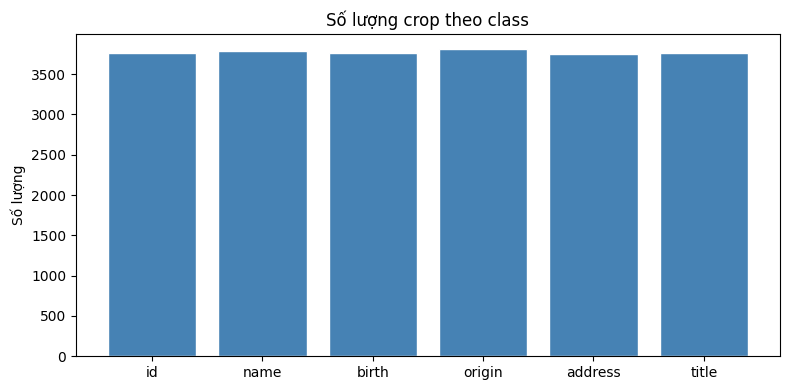

In [5]:
from collections import Counter

count_by_class = Counter(r["class"] for r in all_records)
count_by_split = Counter(r["split"] for r in all_records)
print("Số lượng crop theo class:")
for cls in FIELD_CLASSES:
    print(f"  {cls:10s}: {count_by_class.get(cls, 0):5d}")
print("Số lượng crop theo split:")
for split, cnt in count_by_split.items():
    print(f"  {split:6s}: {cnt}")

# Biểu đồ
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(FIELD_CLASSES, [count_by_class.get(c, 0) for c in FIELD_CLASSES], color="steelblue", edgecolor="white")
ax.set_title("Số lượng crop theo class")
ax.set_ylabel("Số lượng")
plt.tight_layout()
plt.show()

## 5. Xem thử một số crop mẫu

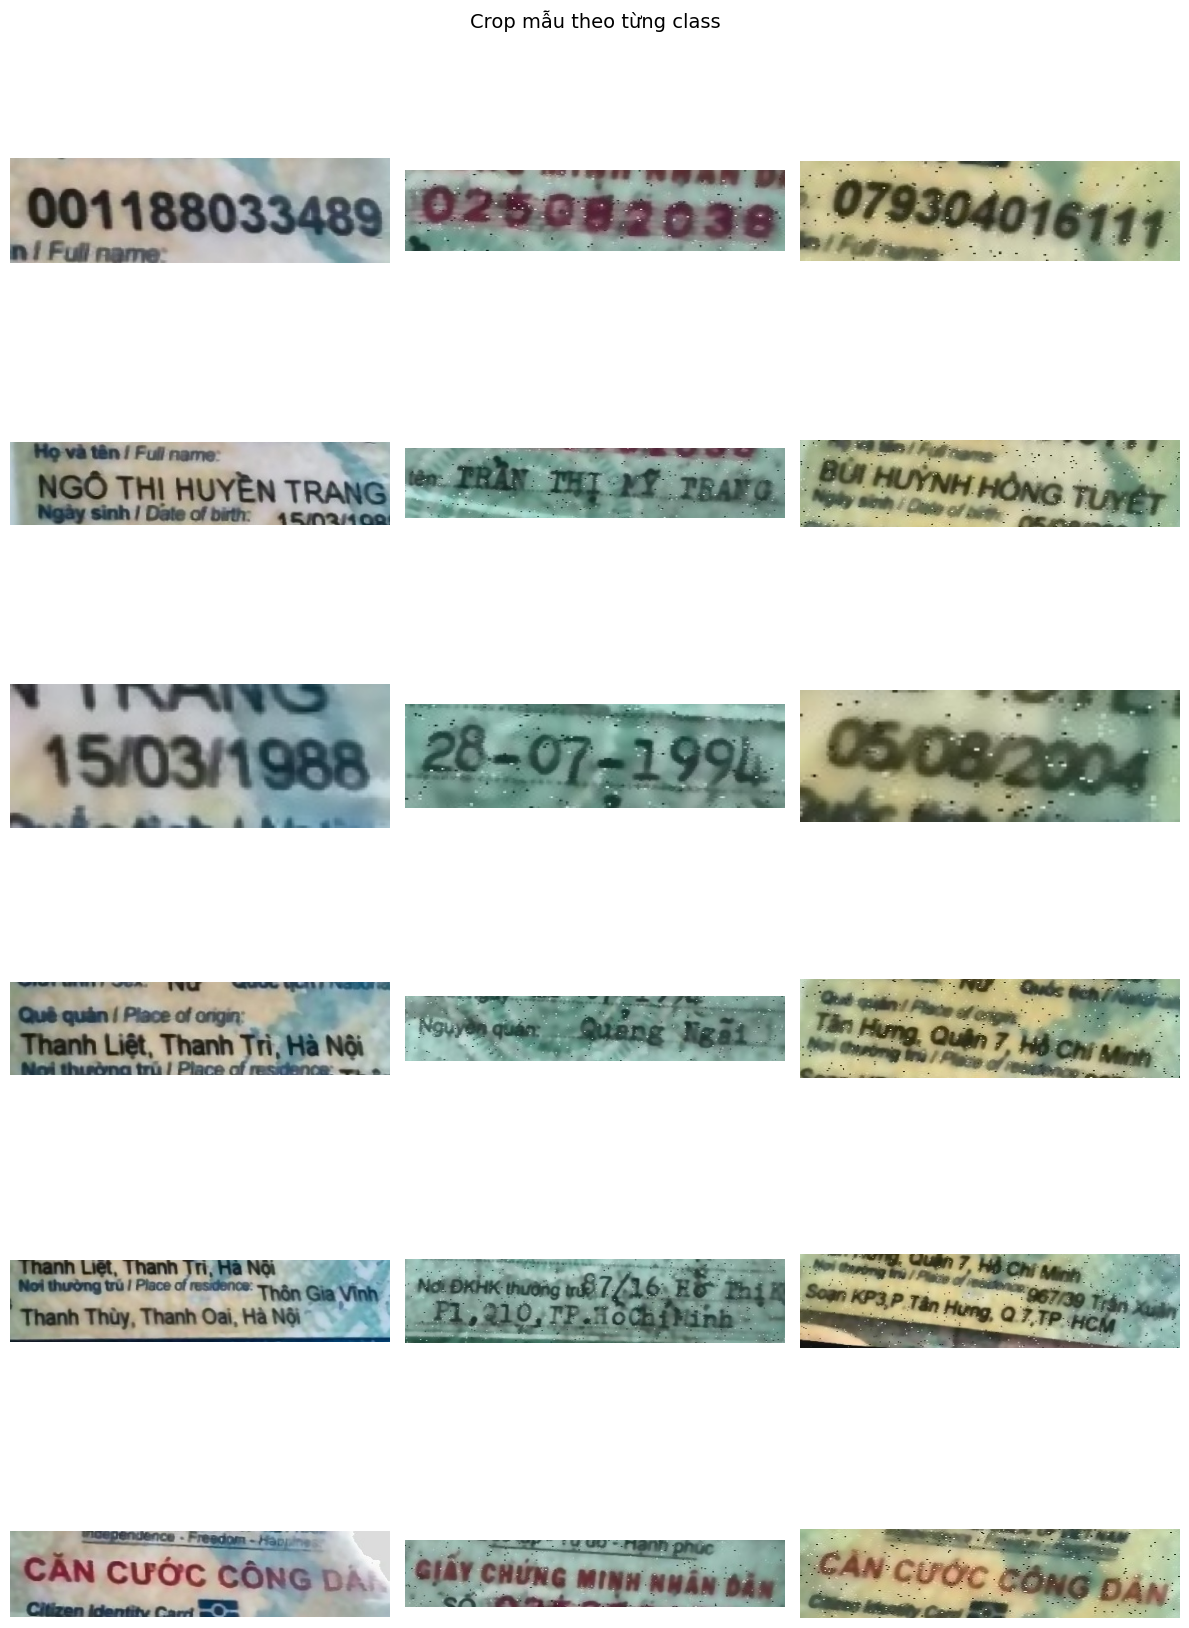

In [6]:
fig, axes = plt.subplots(len(FIELD_CLASSES), 3, figsize=(12, 3 * len(FIELD_CLASSES)))

for row, cls in enumerate(FIELD_CLASSES):
    samples = [r for r in all_records if r["class"] == cls][:3]
    for col, rec in enumerate(samples):
        img = cv2.imread(str(PROJECT_DIR / rec["path"]))
        if img is not None:
            axes[row][col].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[row][col].axis("off")
        if col == 0:
            axes[row][col].set_ylabel(cls, fontsize=12)

plt.suptitle("Crop mẫu theo từng class", fontsize=14)
plt.tight_layout()
plt.show()